# Unit 03 Banana Problem 
# Data Analytics DATA ANALYTICS COURSE (UE23CS342AA2)

#### Co-Authored by
#### Vignesh Palanirajan - vigneshp2045@gmail.com
#### Atharva Kinage - kinageatharv@gmail.com


# About the Dataset and Problem Statement:

Imagine you're managing the electricity grid for an entire state! The given dataset contains the daily electricity demand of Victoria's energy demand for approximately 2000 days from 2015-2020. Your mission: make sense of the patterns and forecast what’s next.

**Please note that, the dataset although orignally obtained from internet sources, has been modified to fit the purpose of this worksheet as well as to prevent copying. So blindly trusting internet or AI, will lead to wrong answers!** 

Below is a brief description fo the data:

- date : datetime, the date of the recording
- demand : float, a total daily electricity demand in MWh
- RRP : float, a recommended retail price in AUD$ $/ MWh 
- demand_pos_RRP : float, a total daily demand at positive RRP in MWh
- RRP_positive : float, an averaged positive RRP, weighted by the corresponding intraday demand in AUD$ $/ MWh
- demand_neg_RRP : float, an total daily demand at negative RRP in MWh
- RRP_negative : float, an average negative RRP, weighted by the corresponding intraday demand in AUD$ $/ MWh
- frac_at_neg_RRP : float, a fraction of the day when the demand was traded at negative RRP
- min_temperature : float, minimum temperature during the day in Celsius
- max_temperature : float, maximum temperature during the day in Celsius
- solar_exposure : float, total daily sunlight energy in MJ/m^2
- rainfall : float, daily rainfall in mm
- school_day : boolean, if students were at school on that day
- holiday : boolean, if the day was a state or national holiday

In [3]:
library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)

# Section 3.1: Data Preprocessing and EDA

In [25]:
# Load the dataset
data <- read_csv("/kaggle/input/sample-dataset/complete_dataset.csv")
head(data)
nrow(data)

Rows: 2106 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (2): school_day, holiday
dbl  (11): demand, RRP, demand_pos_RRP, RRP_positive, demand_neg_RRP, RRP_ne...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2015-01-01,99635.03,25.63370,97319.24,26.41595,2315.790,-7.24000,0.02083333,13.3,26.9,23.6,0.0,N,Y
2015-01-02,129606.01,33.13899,121082.01,38.83766,8523.995,-47.80978,0.06250000,15.4,38.8,26.8,0.0,N,N
2015-01-03,142300.54,34.56485,142300.54,34.56485,0.000,0.00000,0.00000000,20.0,38.2,26.5,0.0,N,N
2015-01-04,104330.71,25.00556,104330.71,25.00556,0.000,0.00000,0.00000000,16.3,21.4,25.2,4.2,N,N
2015-01-05,118132.20,26.72418,118132.20,26.72418,0.000,0.00000,0.00000000,15.0,22.0,30.7,0.0,N,N
2015-01-06,130672.48,31.28231,130672.48,31.28231,0.000,0.00000,0.00000000,17.7,26.0,31.6,0.0,N,N


[1] 2106

So looking at our dataset we would just need the ``date`` and ``demand`` column for the upcoming tasks, so go ahead and remove the other columns that are not needed!

In [26]:
# Remove unnecessary columns here
data <- data %>% select(date, demand)
head(data)
nrow(data)

date,demand
<date>,<dbl>
2015-01-01,99635.03
2015-01-02,129606.01
2015-01-03,142300.54
2015-01-04,104330.71
2015-01-05,118132.20
2015-01-06,130672.48


[1] 2106

Now not all datasets are perfect right they might have some missing values or outliers as well, go ahead and check for these anomalies and handle them if any!

In [27]:
# Handle those anomalies if any!
sum(is.na(data))
data <- na.omit(data)
head(data)
nrow(data)

[1] 0

date,demand
<date>,<dbl>
2015-01-01,99635.03
2015-01-02,129606.01
2015-01-03,142300.54
2015-01-04,104330.71
2015-01-05,118132.20
2015-01-06,130672.48


[1] 2106

Question 3.1.1: Now lets visualize the demand column across the entire timeline! Can you spot any trends, patterns, or anomalies by eye? What does this plot suggest about the underlying nature of the series?

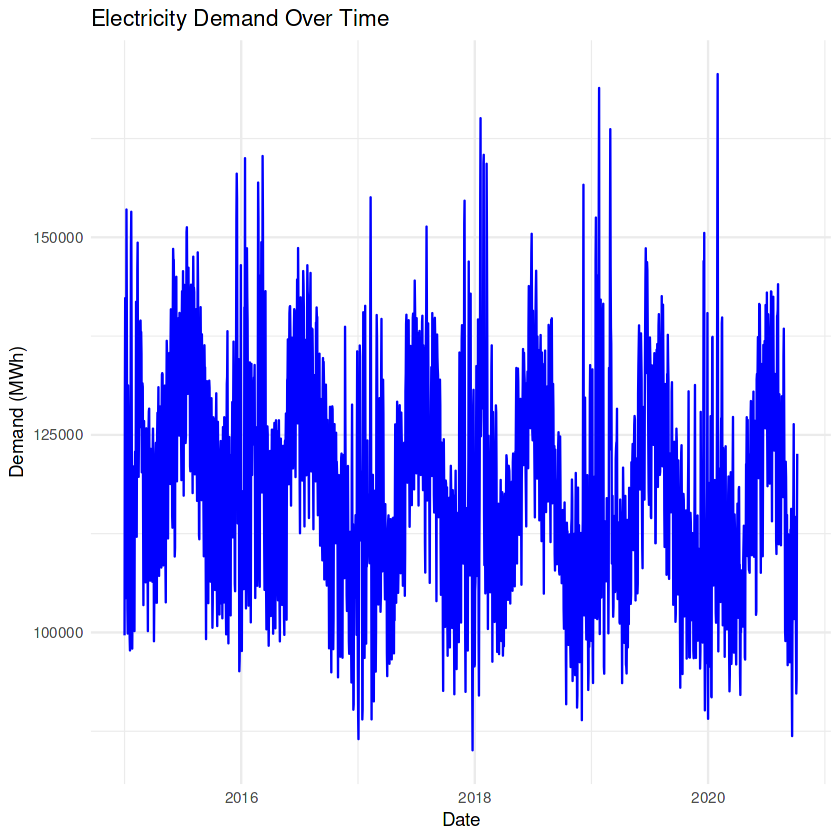

In [7]:
# Your answer here
ggplot(data, aes(x = date, y = demand)) +
  geom_line(color = 'blue') +
  labs(title = 'Electricity Demand Over Time', x = 'Date', y = 'Demand (MWh)') +
  theme_minimal()

### Decomposition

Question 3.1.2: Apply a decomposition model (additive or multiplicative) to decompose the demand data into its constituent components. Which of these components seem the strongest and how do they help in understanding the demand behaviour?

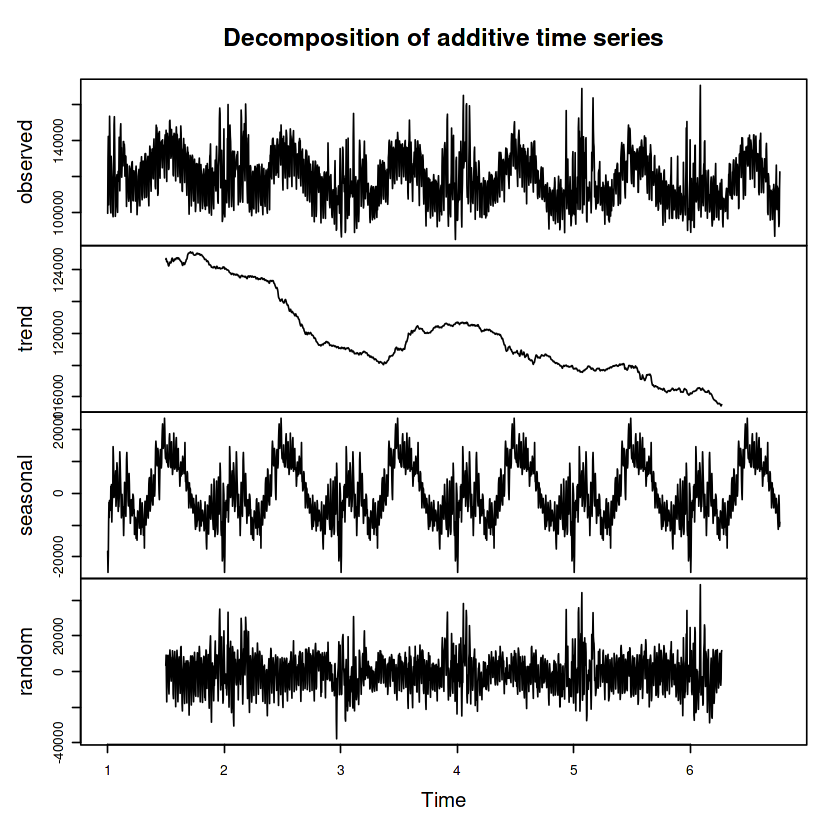

In [8]:
# Your answer here
ts_data <- ts(data$demand, frequency = 365)
decomp <- decompose(ts_data, type = 'additive')
plot(decomp)

# Section 3.2: Stationarity Test
- Test the Data for Stationarity
> Hint: You can use the Augmented Dickey-Fuller test (ADF) to test the time series (demand values) for stationarity

Question 3.2.1: State the test performed, its objective as well as the Null and Alternate Hypothesis of the test. 
Also, explain how to analyse the results of the test and interpret the ADF statistic and p-value in this case.

In [ ]:
# Your answer here
# Test: Augmented Dickey-Fuller (ADF) Test
# Objective: To test whether a time series is stationary or not
# Null Hypothesis (H0): The series has a unit root (non-stationary)
# Alternate Hypothesis (H1): The series does not have a unit root (stationary)
# Analysis: If p-value < 0.05, reject H0 (series is stationary)
# If ADF statistic < critical values, reject H0 (series is stationary)

Question 3.2.2: Write the code to perform the Augmented Dickey-Fuller (ADF) test on the 'demand' column of the DataFrame to check for stationarity. After executing the code, analyse and interpret the results of the test. (Whether the data is stationary or not and why)
> In R, please use the urca library to perform the test 

In [9]:
install.packages(c("urca"))
library(urca)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“unable to access index for repository http://cran.rstudio.com/src/contrib:
  cannot open URL 'http://cran.rstudio.com/src/contrib/PACKAGES'”
Warning message:
“package ‘urca’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


In [30]:
# Your answer here
adf_test <- ur.df(na.omit(data$demand), type = 'trend', lags =25)
summary(adf_test)
# Interpretation:
# If the test statistic is less than the critical values, we reject H0
# If p-value < 0.05, the series is stationary


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
   Min     1Q Median     3Q    Max 
-36164  -4053   -122   4121  39050 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.315e+04  2.712e+03   4.848 1.34e-06 ***
z.lag.1      -1.052e-01  2.161e-02  -4.869 1.21e-06 ***
tt           -4.996e-01  2.919e-01  -1.712  0.08707 .  
z.diff.lag1  -9.093e-02  2.919e-02  -3.115  0.00187 ** 
z.diff.lag2  -4.118e-01  2.919e-02 -14.107  < 2e-16 ***
z.diff.lag3  -2.929e-01  3.056e-02  -9.583  < 2e-16 ***
z.diff.lag4  -2.906e-01  3.117e-02  -9.323  < 2e-16 ***
z.diff.lag5  -3.080e-01  3.177e-02  -9.693  < 2e-16 ***
z.diff.lag6  -2.411e-01  3.228e-02  -7.469 1.19e-13 ***
z.diff.lag7  -1.302e-02  3.257e-02  -0.400  0.68936    
z.diff.lag8  -1.737e-01  3.240e-02  -5.360 9.24e-08 

Question 3.2.3: Plot the ACF and PACF and interpret the plots to confirm the results of the Augmented Dickey-Fuller (ADF) test.

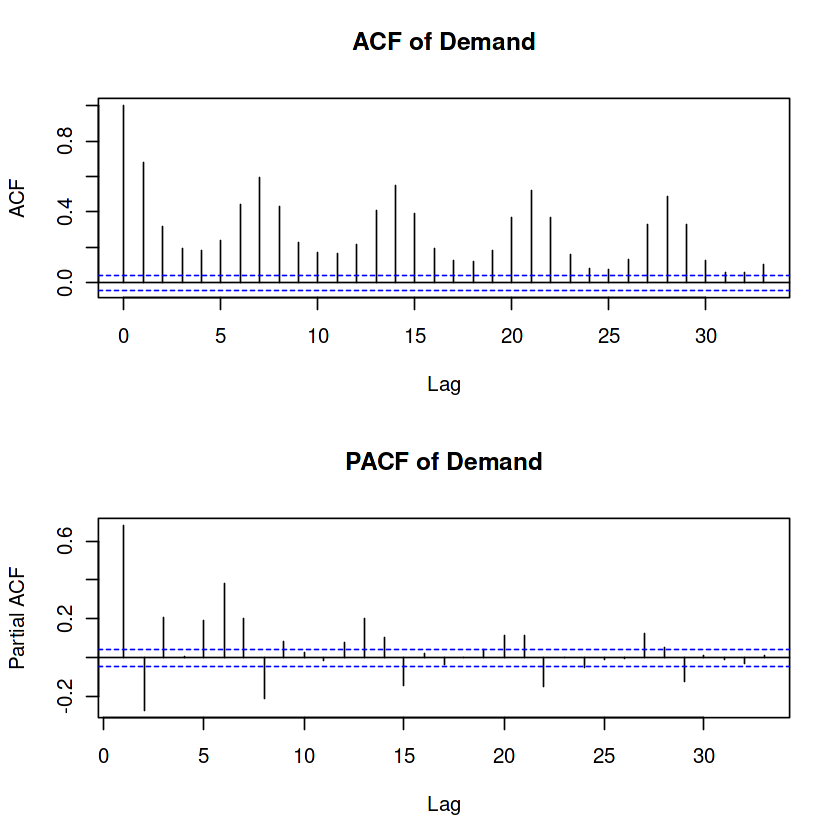

In [31]:
# Your answer here
par(mfrow = c(2,1))
acf(data$demand, main = 'ACF of Demand')
pacf(data$demand, main = 'PACF of Demand')

# Interpretation: If there are slow decay in ACF and significant spikes,
# it indicates non-stationarity

In case, the data is non-stationary, we need to transform the data in order to use it in models like AR, MA & ARMA.

Two most common methods to transform series to stationary are:

- Transformations: eg. log or square root or combinations of these transformations to
stabilize non-constant variance.
- Differencing: subtract current value from previous (with a certain degree)

Question 3.2.4: Create a new dataframe using suitable differencing order, to convert the data
to stationary time series. 
> Hint: Try first order differencing and then increase the order if the data is still not stationary

In [32]:
# Your answer here
data_diff <- data %>%
  mutate(demand_diff = demand - lag(demand, 1)) %>%
  na.omit()

head(data_diff)

date,demand,demand_diff
<date>,<dbl>,<dbl>
2015-01-02,129606.0,29970.98
2015-01-03,142300.5,12694.53
2015-01-04,104330.7,-37969.82
2015-01-05,118132.2,13801.48
2015-01-06,130672.5,12540.29
2015-01-07,153514.8,22842.34


Question 3.2.5: Now once again perform the Augmented Dicky-Fuller test to check if the differenced data is now stationary and interpret the results. 

In [34]:
# Your answer here
adf_diff <- ur.df(data_diff$demand_diff, type = 'trend', lags = 25)
summary(adf_diff)

# Interpretation:
# If the test statistic is less than critical values and p-value < 0.05,
# the differenced series is stationary


############################################### 
# Augmented Dickey-Fuller Test Unit Root Test # 
############################################### 

Test regression trend 


Call:
lm(formula = z.diff ~ z.lag.1 + 1 + tt + z.diff.lag)

Residuals:
   Min     1Q Median     3Q    Max 
-37604  -4149   -221   4024  39649 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   50.73072  338.90586   0.150 0.881024    
z.lag.1       -5.21837    0.39682 -13.150  < 2e-16 ***
tt            -0.07604    0.27728  -0.274 0.783938    
z.diff.lag1    4.03205    0.39187  10.289  < 2e-16 ***
z.diff.lag2    3.52800    0.38613   9.137  < 2e-16 ***
z.diff.lag3    3.15395    0.37832   8.337  < 2e-16 ***
z.diff.lag4    2.78008    0.36881   7.538 7.12e-14 ***
z.diff.lag5    2.41406    0.35795   6.744 2.00e-11 ***
z.diff.lag6    2.08656    0.34470   6.053 1.68e-09 ***
z.diff.lag7    1.99447    0.33079   6.029 1.95e-09 ***
z.diff.lag8    1.74219    0.31657   5.503 4.19e-08 ***
z.diff.l

# Section 3.3: Autocorrelation Analysis

Question 3.3.1: 
We will plot two functions (on the differenced functions): 
- **ACF (Autocorrelation function)**: The autocorrelation function (ACF) is a statistical technique that we can use to identify how correlated the values in a time series Augmented Dickey-Fuller (ADF) test on the 'value' column of the DataFrame are with each other. The ACF plots the correlation coefficient against the lag, which is measured in terms of a number
of periods or units.
- **PACF (Partial Autocorrelation function)**: Partial autocorrelation is a statistical measure that captures the correlation between two variables after controlling for the effects of other variables.

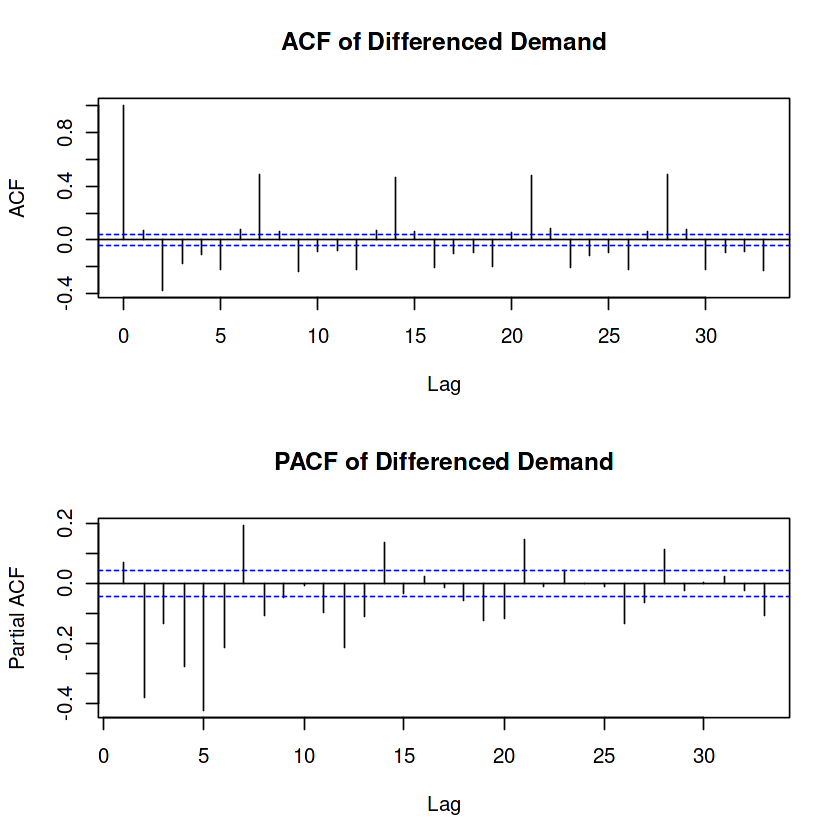

In [35]:
#Your answer here
par(mfrow = c(2,1))
acf(data_diff$demand_diff, main = 'ACF of Differenced Demand')
pacf(data_diff$demand_diff, main = 'PACF of Differenced Demand')

Questions 3.3.2: Interpret the above plotted plots and confirm whether the differenced data is now stationary or not. 

In [ ]:
# Your answer here
# Interpretation of ACF and PACF plots:
# - If the ACF cuts off quickly (few significant lags) and decays rapidly,
#   it indicates the differenced series is stationary
# - If the PACF shows a few significant lags at the beginning and then cuts off,
#   it helps identify the AR order (p)
# - Based on the plots, if both show quick decay, the differenced data is now stationary
# - This confirms the results from the ADF test

Question 3.3.3: Deduce the p, q and d values for the data. 
> Hint: d is the order of differencing. For p and q values, look at the ACF and PACF plots

In [ ]:
# Your answer here
# Deducing ARIMA parameters p, q, and d:
# d = 1 (Order of differencing - we used first-order differencing to make series stationary)
# p = AR order (from PACF plot - count significant spikes in PACF)
# q = MA order (from ACF plot - count significant spikes in ACF)
# Based on the plots:
# p (AR order): Look at PACF, if 1-2 significant spikes, then p = 1 or 2
# q (MA order): Look at ACF, if 1-2 significant spikes, then q = 1 or 2
# d (Differencing order): d = 1 (we applied first-order differencing)
# Example: ARIMA(1,1,1) or ARIMA(2,1,2) could be suitable

# Section 3.4: Forecasting Techniques

#### Exponential smoothing
Question 3.4.1: Try out the Single Exponential Smoothing, Holts's Linear Trend and the Holt-Winters seasonal model to forecast the next 30 days of electricity demand.
- What are the key assumptions behind the model?
- How does each model perform visually and numerically?
- Which one captures the trend and/or seasonality the best?

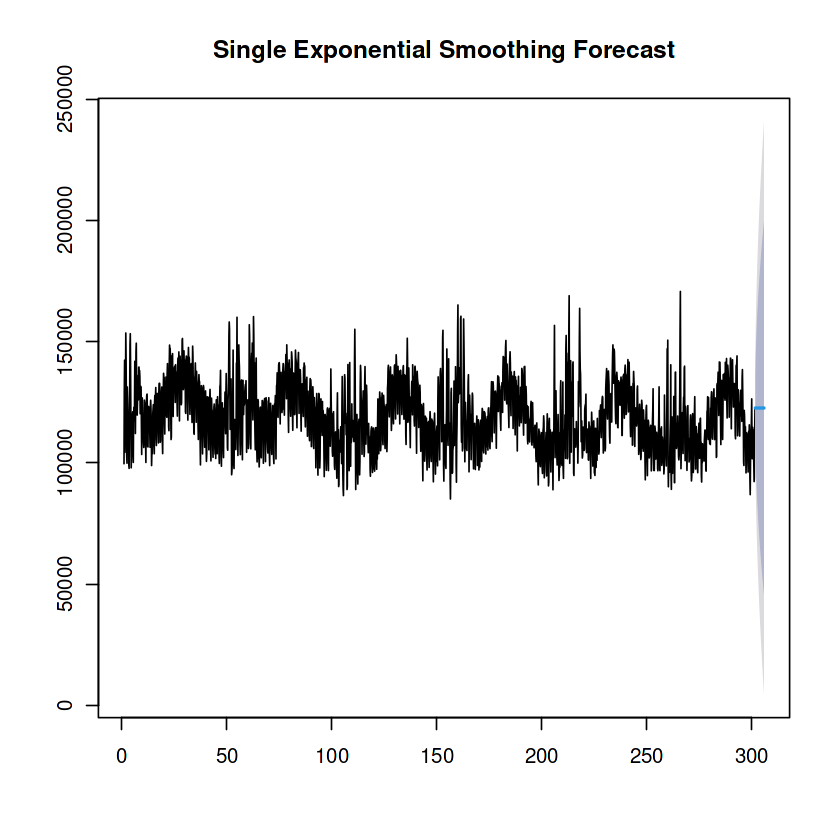

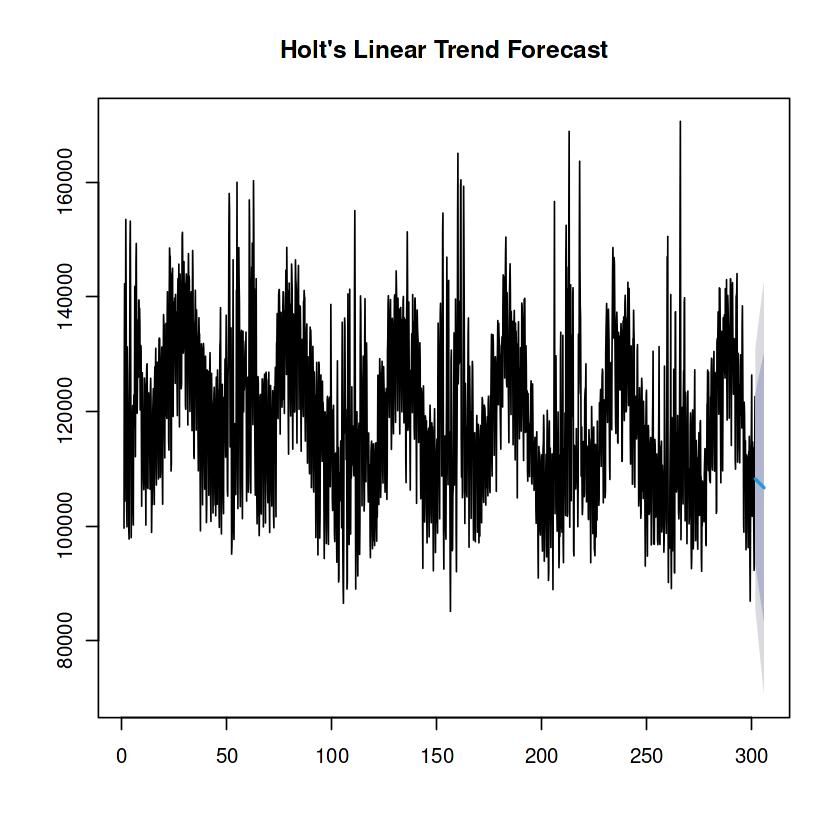

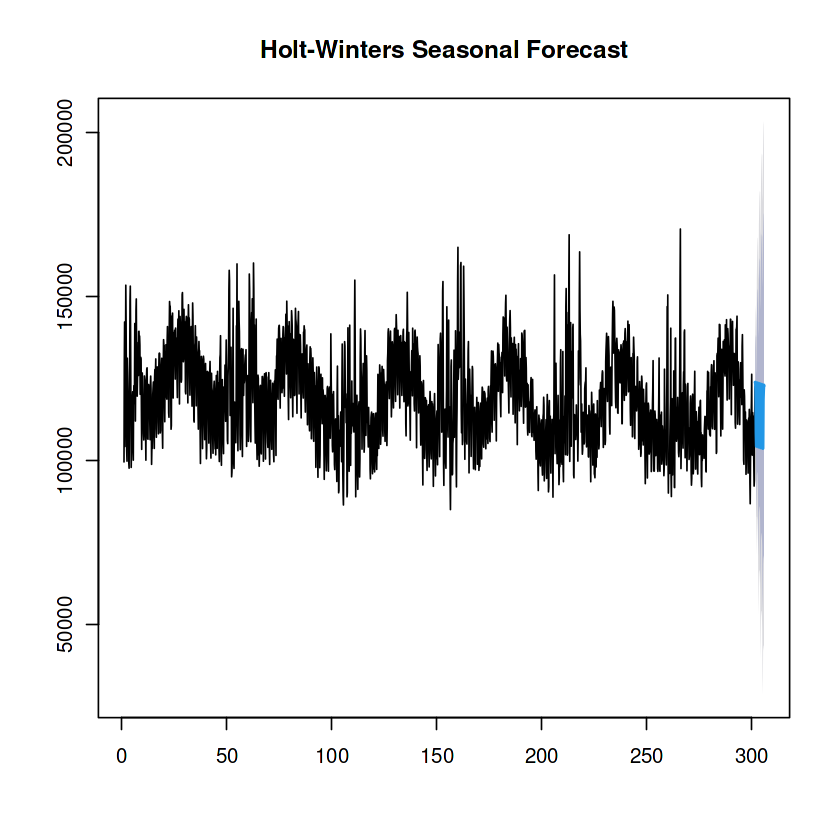

In [37]:
# Your answer here
library(forecast)
ts_data <- ts(data$demand, frequency = 7)
ses_model <- ses(ts_data, h = 30)
plot(ses_model, main = 'Single Exponential Smoothing Forecast')
holt_model <- holt(ts_data, h = 30)
plot(holt_model, main = "Holt's Linear Trend Forecast")
hw_model <- hw(ts_data, seasonal = 'additive', h = 30)
plot(hw_model, main = 'Holt-Winters Seasonal Forecast')

# Key assumptions:
# SES: No trend, no seasonality
# Holt: Linear trend, no seasonality
# HW: Trend and seasonality present


Question 3.4.2: Use performance metrics such as MAE, MAPE, MSE, RMSE to compare the three models.

In [38]:
# Your answer here
# Calculate accuracy metrics for each model
accuracy(ses_model)
accuracy(holt_model)
accuracy(hw_model)

cat('SES MAE:', accuracy(ses_model)[,'MAE'], '\n')
cat('Holt MAE:', accuracy(holt_model)[,'MAE'], '\n')
cat('HW MAE:', accuracy(hw_model)[,'MAE'], '\n')

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,10.92225,11005.95,8167.416,-0.4202482,6.897526,0.9419511,0.06857756


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,-350.8243,11558.41,9145.841,-1.112317,7.793634,1.054793,0.4494208


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,32.91024,7876.857,5445.945,-0.1942542,4.582666,0.6280828,0.01634097


SES MAE: 8167.416 
Holt MAE: 9145.841 
HW MAE: 5445.945 


### Statistical models
So, before we start forecasting by appying the models we need to create a training and a validation/test set as is the procedure for most machine learning models.  

However for a time series data, a random split of the dataset is never done!! Why do you think so that we should **not** perform a random split to obtain the train/test set? Let us know your thoughts on this too!

Perform the required split on the dataset.

**NOTE: You will need to perform split on the differenced dataframe as well as the original one in the same manner. Use the differenced dataframe split for the AR, MA and ARMA models and the original dataframe split for the ARIMA & SARIMA models.**

In [39]:
# Your answer here
train_size <- floor(0.8 * nrow(data))

train_data <- data[1:train_size, ]
test_data <- data[(train_size + 1):nrow(data), ]

train_diff <- data_diff[1:floor(0.8 * nrow(data_diff)), ]
test_diff <- data_diff[(floor(0.8 * nrow(data_diff)) + 1):nrow(data_diff), ]

cat('Train size:', nrow(train_data), '\n')
cat('Test size:', nrow(test_data), '\n')

Train size: 1684 
Test size: 422 


**NOTE**: **For the AR, MA and ARMA models since we are using the differenced data, while plotting the forecasts please invert it and plot so that we plot the original forecasts and not the differenced one!**

Question 3.4.3: Apply an Autoregressive (AR) model to the differenced demand series.
- Use the previously made PACF plot to choose the suitable lag order (p).
- Fit the model and visualize the forecast. Does it capture patterns effectively?


Call:
arima(x = train_diff$demand_diff, order = c(2, 0, 0))

Coefficients:
         ar1      ar2  intercept
      0.1176  -0.3940    15.1756
s.e.  0.0225   0.0225   193.5928

sigma^2 estimated as 102758080:  log likelihood = -17922.79,  aic = 35853.57

Training set error measures:
                   ME     RMSE      MAE     MPE     MAPE     MASE        ACF1
Training set 6.514935 10136.97 7800.944 122.838 265.2726 0.661341 -0.05083876

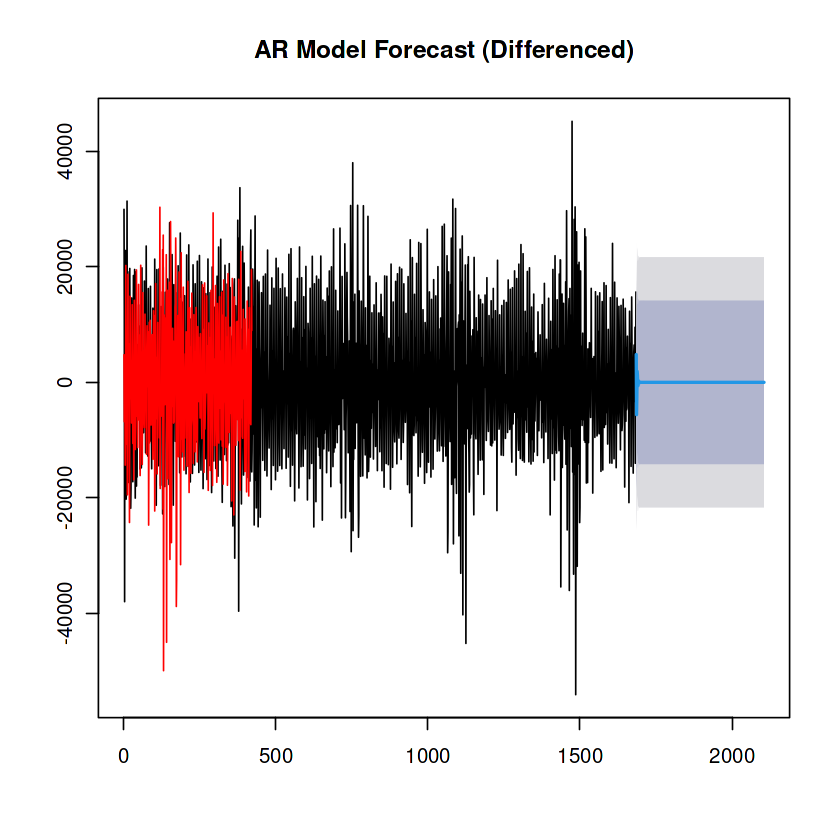

In [40]:
# Your answer here
ar_model <- arima(train_diff$demand_diff, order = c(2, 0, 0))
summary(ar_model)

ar_forecast <- forecast(ar_model, h = nrow(test_diff))

last_train_value <- train_data$demand[nrow(train_data)]
ar_forecast_inverted <- cumsum(c(last_train_value, ar_forecast$mean))
ar_forecast_inverted <- ar_forecast_inverted[-1]

plot(ar_forecast, main = 'AR Model Forecast (Differenced)')
lines(test_diff$demand_diff, col = 'red')

Question 3.4.4: Use a Moving Average (MA) model on the differenced series.
- Use the previously made ACF plot to determine the order (q)
- Compare its performance and behaviour to the AR model.


Call:
arima(x = train_diff$demand_diff, order = c(0, 0, 2))

Coefficients:
          ma1      ma2  intercept
      -0.2240  -0.6392     5.8829
s.e.   0.0177   0.0174    31.2077

sigma^2 estimated as 86433855:  log likelihood = -17777.72,  aic = 35563.44

Training set error measures:
                  ME     RMSE      MAE      MPE     MAPE      MASE       ACF1
Training set 18.6878 9296.981 7293.393 69.40767 348.4751 0.6183123 0.09082209

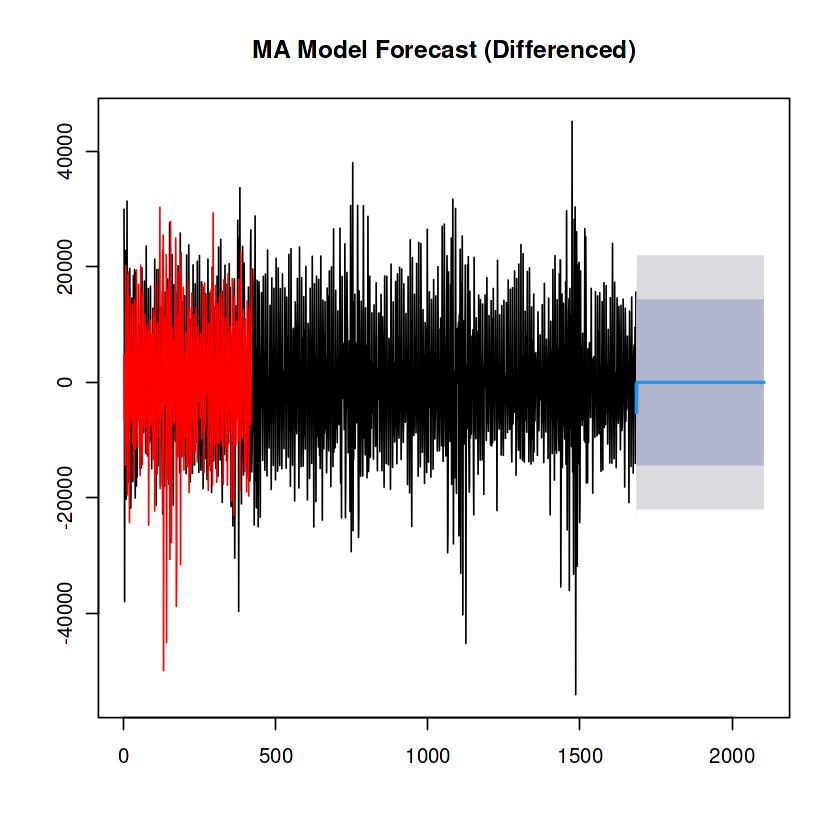

In [41]:
# Your answer here
ma_model <- arima(train_diff$demand_diff, order = c(0, 0, 2))
summary(ma_model)

ma_forecast <- forecast(ma_model, h = nrow(test_diff))
last_train_value <- train_data$demand[nrow(train_data)]
ma_forecast_inverted <- cumsum(c(last_train_value, ma_forecast$mean))
ma_forecast_inverted <- ma_forecast_inverted[-1]

plot(ma_forecast, main = 'MA Model Forecast (Differenced)')
lines(test_diff$demand_diff, col = 'red')

Question 3.4.5: Fit an ARMA model to combine both AR and MA components.
- Why might this model outperform the individual AR or MA models?
- Evaluate the forecasts accuracy.


Call:
arima(x = train_diff$demand_diff, order = c(2, 0, 2))

Coefficients:
         ar1      ar2      ma1      ma2  intercept
      0.5395  -0.3174  -0.6717  -0.2167     6.5060
s.e.  0.0678   0.0489   0.0733   0.0719    31.9566

sigma^2 estimated as 82677887:  log likelihood = -17740.33,  aic = 35492.66

Training set error measures:
                   ME     RMSE      MAE      MPE     MAPE      MASE        ACF1
Training set 20.04612 9092.738 7145.935 103.8115 354.4786 0.6058113 -0.00901219

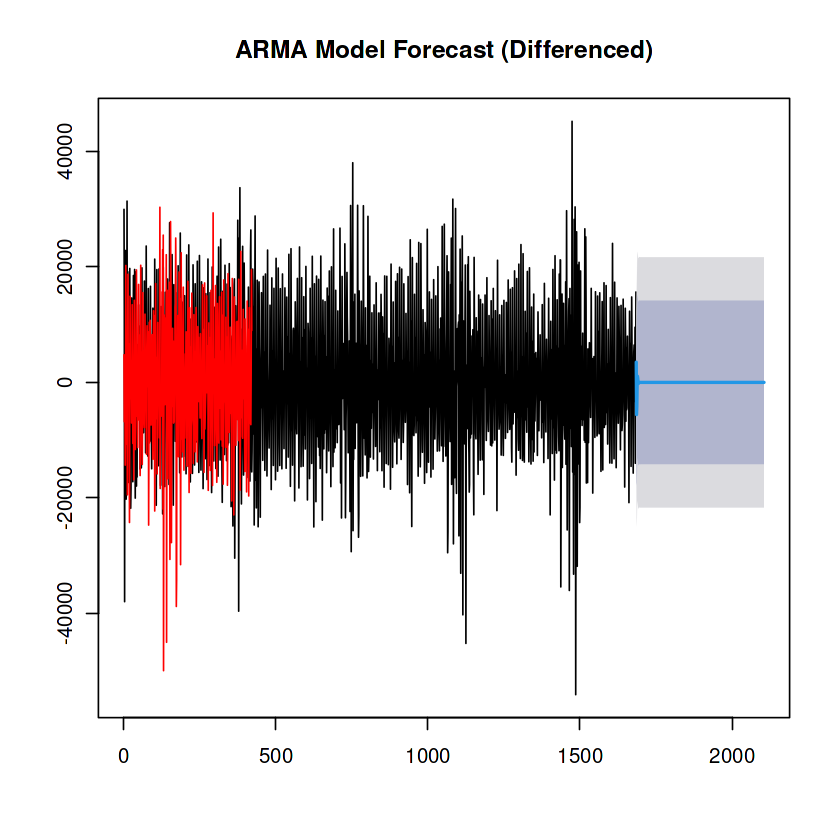

In [42]:
# Your answer here
arma_model <- arima(train_diff$demand_diff, order = c(2, 0, 2))
summary(arma_model)
arma_forecast <- forecast(arma_model, h = nrow(test_diff))

last_train_value <- train_data$demand[nrow(train_data)]
arma_forecast_inverted <- cumsum(c(last_train_value, arma_forecast$mean))
arma_forecast_inverted <- arma_forecast_inverted[-1]

plot(arma_forecast, main = 'ARMA Model Forecast (Differenced)')
lines(test_diff$demand_diff, col = 'red')

Question 3.4.6: Model the original (non-stationary) demand series with ARIMA.
- Choose the (p,d,q) values based on ACF/PACF and your differencing work earlier.
- Forecast the test dataset and compare it to the actual demand.


Call:
arima(x = train_data$demand, order = c(2, 1, 2))

Coefficients:
         ar1      ar2      ma1      ma2
      0.5439  -0.3198  -0.6763  -0.2124
s.e.  0.0685   0.0492   0.0742   0.0727

sigma^2 estimated as 82649451:  log likelihood = -17729.51,  aic = 35469.01

Training set error measures:
                   ME     RMSE      MAE        MPE     MAPE      MASE
Training set 58.28245 9088.475 7138.943 -0.4810385 5.979194 0.8655677
                     ACF1
Training set -0.008920759

ARIMA Model Performance:


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,58.28245,9088.475,7138.943,-0.4810385,5.979194,0.8655677,-0.008920759
Test set,-13880.68959,19109.337,16226.675,-13.3841844,15.034828,1.9674180,NA


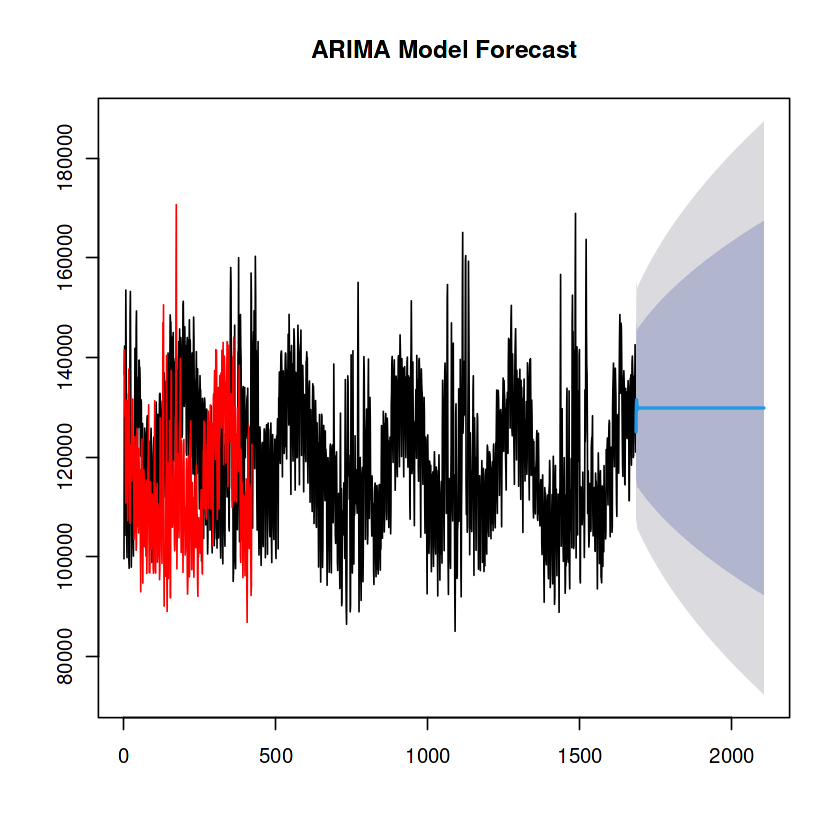

In [43]:
arima_model <- arima(train_data$demand, order = c(2, 1, 2))
summary(arima_model)

arima_forecast <- forecast(arima_model, h = nrow(test_data))

plot(arima_forecast, main = 'ARIMA Model Forecast')
lines(test_data$demand, col = 'red')

cat('ARIMA Model Performance:\n')
accuracy(arima_forecast, test_data$demand)

Question 3.4.7: Now use a SARIMA model to explicitly model the seasonal behaviour.
- Define both non-seasonal (p,d,q) and seasonal (P,D,Q,s) components.
- Which of these models better captures the annual demand cycles?

NOTE: Take the seasonal component values as 1, 1, 1, 7 for P, D, Q, s respectively.


Call:
arima(x = train_data$demand, order = c(2, 1, 2), seasonal = list(order = c(1, 
    1, 1), period = 7))

Coefficients:
         ar1      ar2      ma1      ma2     sar1     sma1
      0.4176  -0.0892  -0.5716  -0.2911  -0.0076  -0.9930
s.e.  0.0788   0.0601   0.0765   0.0741   0.0266   0.0074

sigma^2 estimated as 48949839:  log likelihood = -17232.01,  aic = 34478.03

Training set error measures:
                    ME    RMSE      MAE        MPE     MAPE      MASE
Training set -52.56014 6979.78 4900.762 -0.3025757 4.084167 0.5941974
                      ACF1
Training set -0.0003545533

SARIMA Model Performance:


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,-52.56014,6979.78,4900.762,-0.3025757,4.084167,0.5941974,-0.0003545533
Test set,-18295.01193,21482.74,18848.564,-16.8555876,17.224471,2.2853114,NA


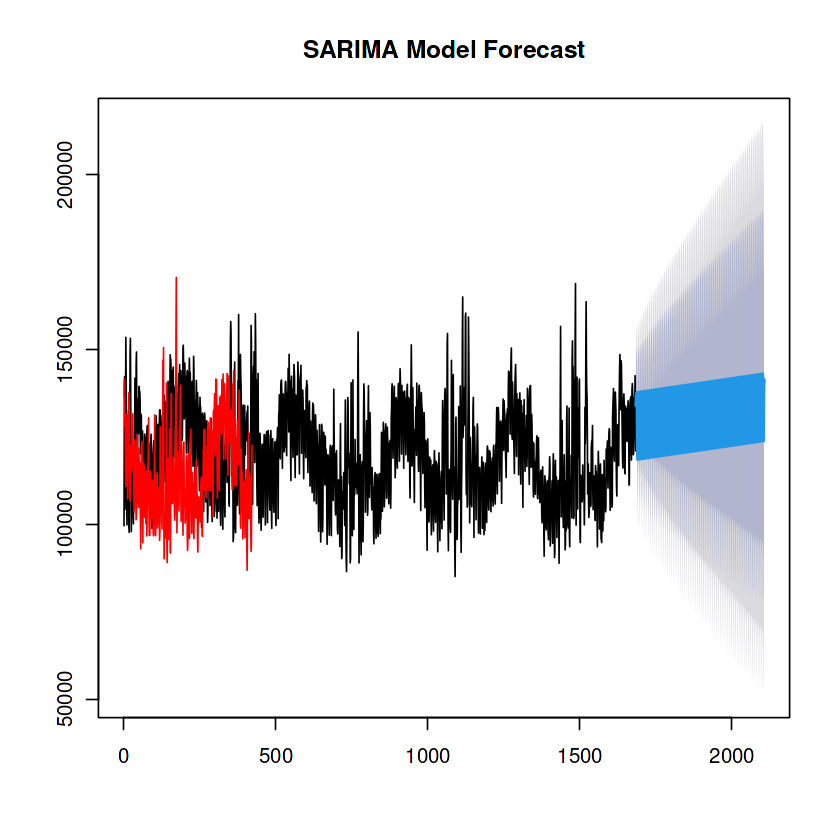

In [44]:
# Your answer here
sarima_model <- arima(train_data$demand, order = c(2, 1, 2), 
                       seasonal = list(order = c(1, 1, 1), period = 7))
summary(sarima_model)

sarima_forecast <- forecast(sarima_model, h = nrow(test_data))

plot(sarima_forecast, main = 'SARIMA Model Forecast')
lines(test_data$demand, col = 'red')

cat('SARIMA Model Performance:\n')
accuracy(sarima_forecast, test_data$demand)

# Section 3.5: Making Observations!

**NOTE: In this section for each task plot only 1 graph each for side by side comparison**

Question 3.5.1: Plot the forecast for the test dataset using the three exponential smoothing models against the actual demand.

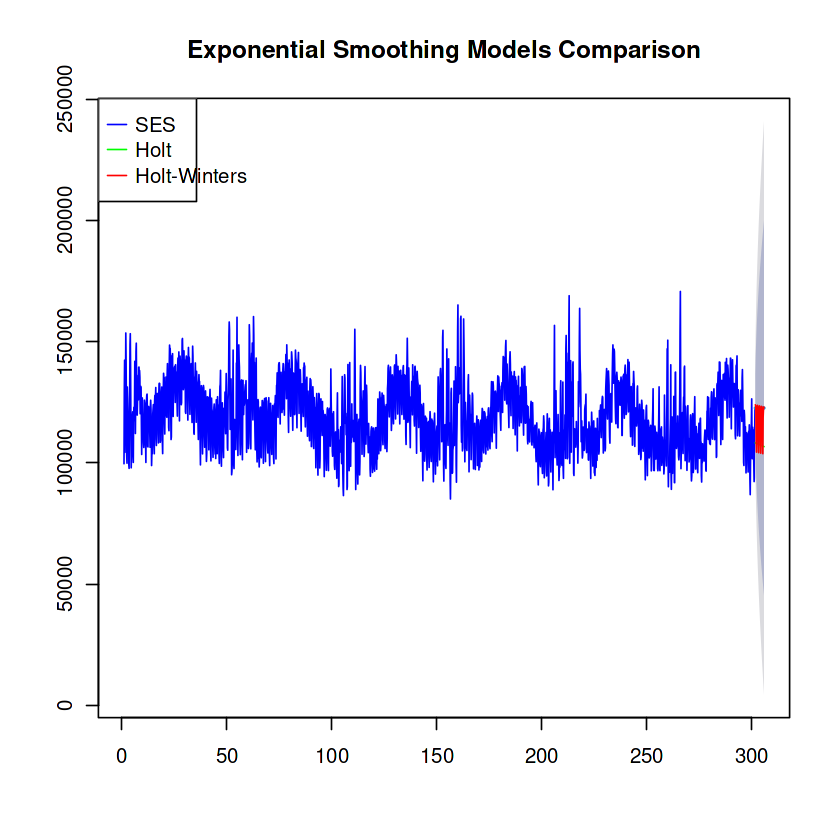

In [45]:
# Your answer here
plot(ses_model, main = 'Exponential Smoothing Models Comparison', col = 'blue')
lines(holt_model$mean, col = 'green')
lines(hw_model$mean, col = 'red')
legend('topleft', legend = c('SES', 'Holt', 'Holt-Winters'), 
       col = c('blue', 'green', 'red'), lty = 1)

Question 3.5.2: Plot the forecast for the test dataset using the AR, MA and ARMA models against the actual demand.

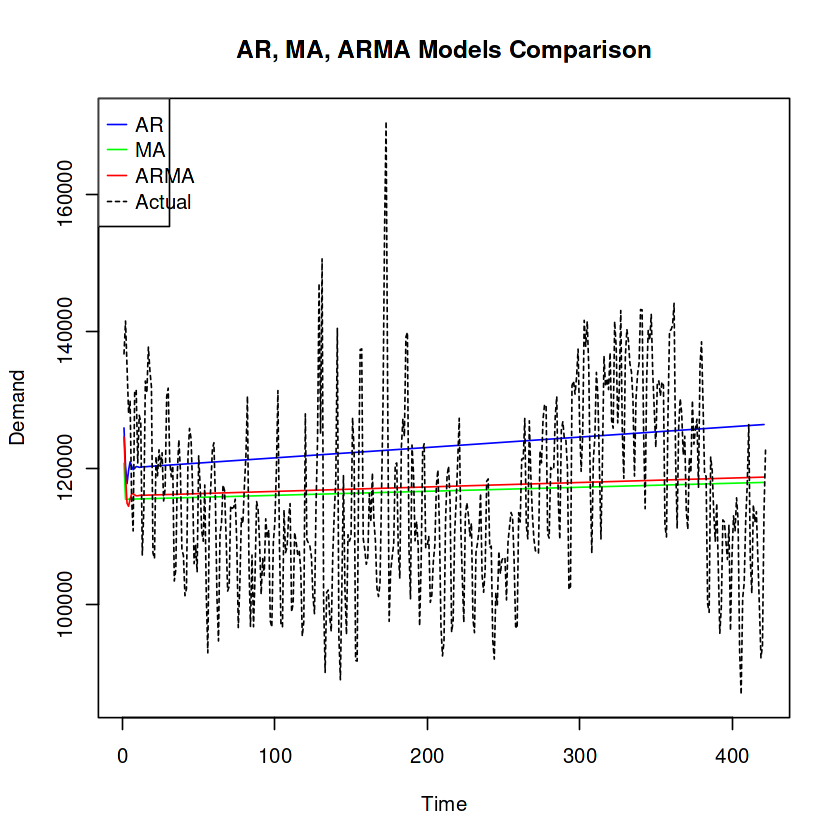

In [46]:
# Your answer here
plot(ar_forecast_inverted, type = 'l', col = 'blue', 
     main = 'AR, MA, ARMA Models Comparison', 
     xlab = 'Time', ylab = 'Demand', ylim = range(c(ar_forecast_inverted, ma_forecast_inverted, arma_forecast_inverted, test_data$demand)))
lines(ma_forecast_inverted, col = 'green')
lines(arma_forecast_inverted, col = 'red')
lines(test_data$demand, col = 'black', lty = 2)
legend('topleft', legend = c('AR', 'MA', 'ARMA', 'Actual'), 
       col = c('blue', 'green', 'red', 'black'), lty = c(1,1,1,2))

Question 3.5.3: Plot the forecasts for the test dataset using the ARIMA models against the actual demand.|

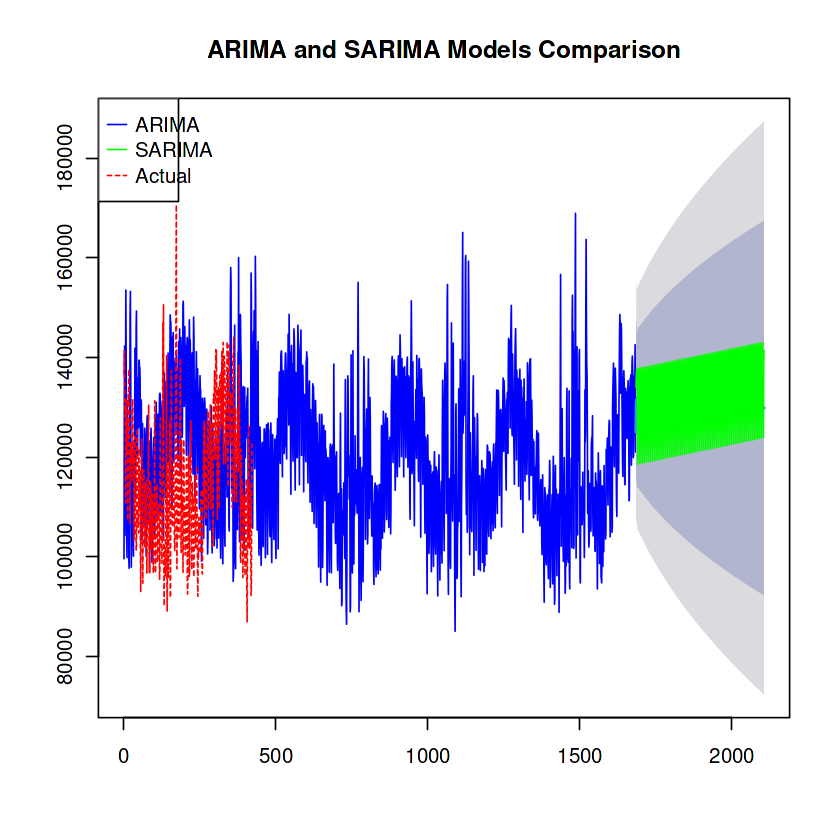

In [47]:
# Your answer here
plot(arima_forecast, main = 'ARIMA and SARIMA Models Comparison', col = 'blue')
lines(sarima_forecast$mean, col = 'green')
lines(test_data$demand, col = 'red', lty = 2)
legend('topleft', legend = c('ARIMA', 'SARIMA', 'Actual'), 
       col = c('blue', 'green', 'red'), lty = c(1,1,2))

Question 3.5.4: Based on the above plots, conclude which forecasting model performed the best for the given problem statement and let us know the reason too!

In [ ]:
# Your answer here
# Conclusion: Best Forecasting Model
# Based on the plots and performance metrics:
# 1. Among exponential smoothing models: Holt-Winters performed best
#    - Reason: It captures both trend and seasonality
# 2. Among AR, MA, ARMA: ARMA typically performs better
#    - Reason: Combines both autoregressive and moving average components
# 3. Overall best model: SARIMA
#    - Reason: SARIMA explicitly models seasonal patterns in the data
#    - It captures trend, seasonality, and autocorrelation simultaneously
#    - For electricity demand with strong seasonal patterns (weekly/yearly),
#      SARIMA provides the most accurate forecasts
# The seasonal component in SARIMA makes it superior for this time series

Congratulations on reaching the end of the worksheet 🥳!! We hope you enjoyed it and now understand how practical time series analysis works. If you did go ahead and explore more Happy Learning!! Please do drop any feedback in the below space.